In [26]:
from pathlib import Path 
import os 
import sys
import matplotlib.pyplot as plt 
import scanpy as sc
import numpy as np 
import pandas as pd
import scipy as sp 
import seaborn as sns
from tqdm import tqdm 
import copy
import math
import yaml
import fpsample
import pickle as pkl

## Read data frames 

In [27]:
with open("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/original/fitlered_populations.pkl", "rb") as file:
    filtered_df_original = pkl.load(file)

In [28]:
with open("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/original_plus_LPHO012/fitlered_populations.pkl", "rb") as file:
    filtered_df_original_LPHO012 = pkl.load(file)

In [29]:
ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]
protocol_cols = [name for name in protocol_cols]

## Concatenate

In [30]:
df_concatenated = {}

for cell_type in filtered_df_original:
    df_original = filtered_df_original[cell_type]
    df_LPHO012 = filtered_df_original_LPHO012[cell_type]
    df_original["dataset"] = "Original"
    df_LPHO012["dataset"] = "LPH12"
    df_concatenated[cell_type] = pd.concat([df_original, df_LPHO012], axis=0)

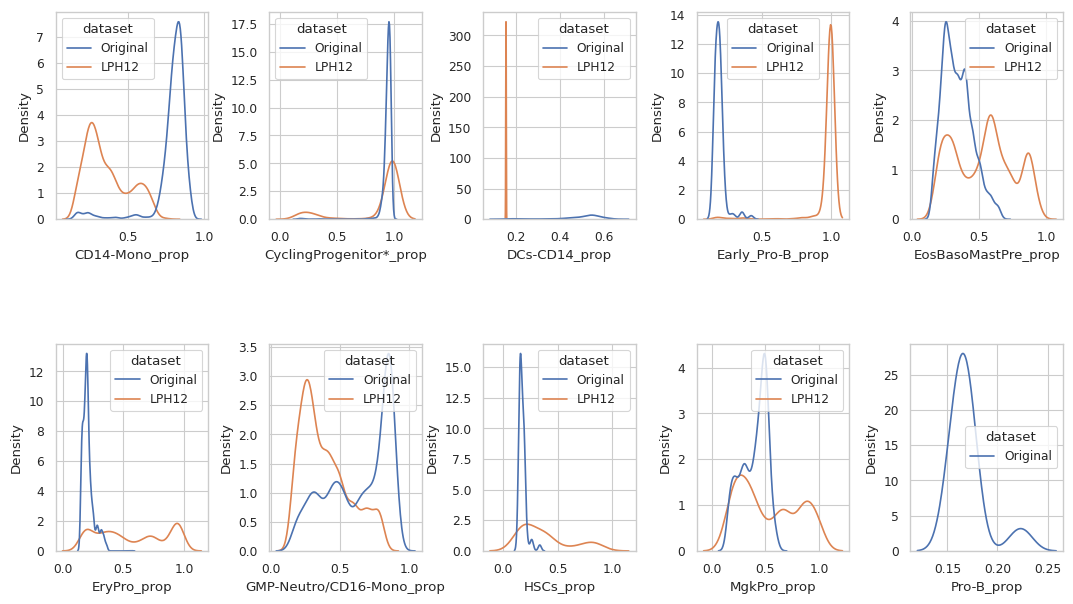

In [37]:
sns.set(style="whitegrid", context="paper")

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(13,7))
fig.subplots_adjust(
    hspace=0.6,   # vertical space between rows
    wspace=0.4    # horizontal space between columns
)
axes = axes.flatten()  # make indexing easy

for i, cell_type in enumerate(df_concatenated):
    cell_type_safe = cell_type.replace(":", "/")
    df_plot = df_concatenated[cell_type].reset_index(drop=True)

    ax = axes[i]

    sns.kdeplot(
        data=df_plot,
        x=f"{cell_type_safe}_prop",
        hue="dataset",
        ax=ax,
        common_norm=False
    )


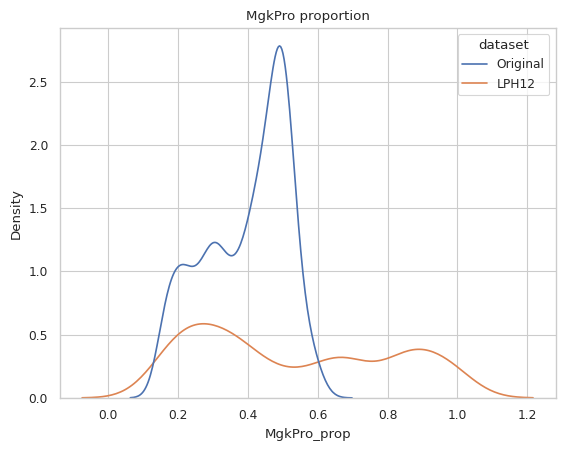

In [40]:
sns.kdeplot(df_concatenated["MgkPro"], x="MgkPro_prop", hue="dataset")
plt.title("MgkPro proportion")
plt.show()

# Distances from sakurai

In [44]:
sakurai_medium = np.array([0, 0, 0, 70, 0, 0, 100, 0, 0, 0, 20, 14])

In [48]:
df_concatenated["MgkPro"]["sakurai_dist"] = sp.spatial.distance.cdist(df_concatenated["MgkPro"].loc[:, protocol_cols].values, 
                                                     sakurai_medium[None])

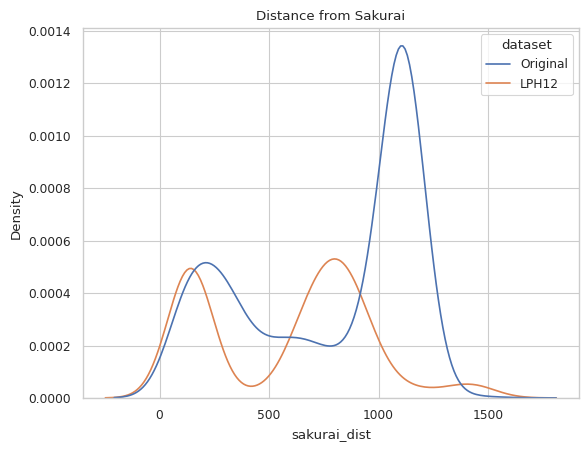

In [49]:
sns.kdeplot(df_concatenated["MgkPro"], x="sakurai_dist", hue="dataset")
plt.title("Distance from Sakurai")
plt.show()